# RQ3: Hitzewellen in europäischen Großstädten (1980–2025)

Dieses Notebook untersucht, wie sich Häufigkeit, Intensität und Dauer von Hitzewellen in europäischen Großstädten seit 1980 verändert haben. Eine "Hitzewelle" ist hier nach der Definition des Deutschen Wetterdienstes (DWD) definiert: mindestens 3 aufeinanderfolgende Tage, die sowohl ungewöhnlich heiß für die jeweilige Stadt als auch in absoluten Zahlen heiß sind (siehe Zelle 9 für Details).

**Grober Ablauf:** Städte auswählen (Zelle 2) → Wetterdaten für zwei Zeiträume laden (Zellen 13–16): eine "Referenzperiode" 1961–1990, um zu wissen, was für jede Stadt normal war, und den eigentlichen Analysezeitraum 1980–2025 → Hitzewellen erkennen (Zellen 17–20) → Ergebnisse auswerten und visualisieren (Zellen 21–30).

Zelle 2 — Europäische Großstädte + Hauptstädte laden

Diese Zelle lädt die Städteliste: alle Städte mit ≥500.000 Einwohnern in den Ländern aus `european_countries`, ergänzt um die jeweilige Landeshauptstadt — auch wenn diese unter 500.000 Einwohner hat (z. B. Reykjavik, Ljubljana, Vaduz, Valletta). Warum Hauptstädte extra dazu? Weil sonst kleine, aber politisch/wirtschaftlich wichtige Länder komplett fehlen würden.

Datenquelle ist die GeoNames-API (eine kostenlose, offene Datenbank für Orte weltweit), abgefragt in zwei Schritten pro Land:

1. `featureClass=P` ("populated place") + Populationsfilter ≥500.000
2. `featureCode=PPLC` (Hauptstadt), mit Fallback `PPLA` (Verwaltungssitz) für Fälle, in denen GeoNames keine Hauptstadt-Markierung führt (kommt bei kleinen Territorien vor)

Ergebnis ist `cities_df` mit den Spalten `city`, `country`, `population`, `lat`, `lon`, `is_capital`. Duplikate (z. B. weil eine Hauptstadt auch über den Populationsfilter gefunden wurde) werden zusammengeführt. Damit das nicht bei jedem Neustart des Notebooks erneut ~150 Anfragen an GeoNames schickt, wird das Ergebnis einmalig lokal als CSV-Datei gespeichert und beim nächsten Mal von dort gelesen.

Hinweis: In `european_countries` fehlt Zypern (CY) — falls das kein Versehen war, unten in der Liste ergänzen.

In [33]:
# Zelle 2
# Europäische Großstädte (>=500.000 Einwohner) + Landeshauptstädte, via GeoNames-Search-API
import requests
import pandas as pd
import numpy as np
import time
import os

european_countries = [
    "AD", "AL", "AT", "AX", "BA", "BE", "BG", "BY",
    "CH", "CZ", "DE", "DK", "EE", "ES", "FI", "FO",
    "FR", "GB", "GG", "GI", "GR", "HR", "HU", "IE",
    "IM", "IS", "IT", "JE", "LI", "LT", "LU", "LV",
    "MC", "MD", "ME", "MK", "MT", "NL", "NO", "PL",
    "PT", "RO", "RS", "SE", "SI", "SJ", "SK",
    "SM", "UA", "VA"
]

GEONAMES_URL = "https://secure.geonames.org/searchJSON"
GEONAMES_USER = "timos98"
CITIES_CACHE_PATH = "data/raw/cities_europe.csv"  # lokaler Cache, damit wir GeoNames nicht bei jedem Neustart neu fragen


def _place_row(place, is_capital):
    # Wandelt eine einzelne GeoNames-Antwort in unser einheitliches Zeilenformat um.
    # lat/lon (statt latitude/longitude) und geoname_id sind bewusst so benannt,
    # weil der Rest des Notebooks genau diese Namen erwartet.
    return {
        "geoname_id": place.get("geonameId"),   # eindeutige GeoNames-ID -> nutzen wir später zum Duplikate-Entfernen
        "city": place.get("name"),
        "country": place.get("countryName"),
        "country_code": place.get("countryCode"),
        "population": int(place.get("population", 0) or 0),  # "or 0" fängt den Fall ab, dass population leer/None ist
        "lat": float(place.get("lat")),
        "lon": float(place.get("lng")),
        "is_capital": is_capital,
    }


def fetch_large_cities(country, min_population=500000, pause=1.0):
    """Alle Städte eines Landes mit Einwohnerzahl >= min_population."""
    rows, start_row = [], 0
    while True:
        # GeoNames liefert maximal 1000 Treffer pro Anfrage -> bei Bedarf mit startRow "umblättern"
        params = {
            "country": country, "featureClass": "P",
            "maxRows": 1000, "startRow": start_row,
            "username": GEONAMES_USER,
        }
        try:
            r = requests.get(GEONAMES_URL, params=params, timeout=30)
            r.raise_for_status()
            places = r.json().get("geonames", [])
        except Exception as e:
            print(f"  Fehler bei {country} (Populationssuche, startRow={start_row}): {e}")
            break

        if not places:
            break  # keine weiteren Seiten mehr für dieses Land
        for place in places:
            if int(place.get("population", 0) or 0) >= min_population:
                rows.append(_place_row(place, is_capital=False))
        start_row += 1000
        time.sleep(pause)  # kurze Pause, um GeoNames nicht mit Anfragen zu überfluten
    return rows


def fetch_capital(country, pause=1.0):
    """Hauptstadt eines Landes: featureCode PPLC, sonst Fallback PPLA."""
    for feature_code in ("PPLC", "PPLA"):
        params = {
            "country": country, "featureCode": feature_code,
            "maxRows": 1, "username": GEONAMES_USER,
        }
        try:
            r = requests.get(GEONAMES_URL, params=params, timeout=30)
            r.raise_for_status()
            places = r.json().get("geonames", [])
        except Exception as e:
            print(f"  Fehler bei {country} (Hauptstadtsuche, {feature_code}): {e}")
            places = []
        time.sleep(pause)
        if places:
            return _place_row(places[0], is_capital=True)
    print(f"  Keine Hauptstadt gefunden für {country} (weder PPLC noch PPLA)")
    return None


def get_european_cities(min_population=500000):
    all_rows = []
    for country in european_countries:
        all_rows.extend(fetch_large_cities(country, min_population=min_population))
        cap = fetch_capital(country)
        if cap is not None:
            all_rows.append(cap)

    df = pd.DataFrame(all_rows)
    # Duplikate (gleiche geoname_id) zusammenführen: sort_values sorgt dafür, dass
    # bei einem Duplikat die Zeile mit is_capital=True zuerst kommt, drop_duplicates
    # behält dann automatisch genau diese (keep="first").
    df = (df.sort_values("is_capital", ascending=False)
            .drop_duplicates(subset="geoname_id", keep="first"))
    return df.sort_values("population", ascending=False).reset_index(drop=True)


# Cache-Logik: Datei existiert schon -> einlesen statt neu von GeoNames zu laden.
if os.path.exists(CITIES_CACHE_PATH):
    cities_df = pd.read_csv(CITIES_CACHE_PATH)
    print(f"cities_df aus Cache geladen: {CITIES_CACHE_PATH}")
else:
    cities_df = get_european_cities(min_population=500000)
    os.makedirs("data/raw", exist_ok=True)
    cities_df.to_csv(CITIES_CACHE_PATH, index=False)
    print(f"cities_df neu von GeoNames geladen und gespeichert: {CITIES_CACHE_PATH}")

print(cities_df)
print(f"Anzahl Städte: {len(cities_df)}")
print(f"davon nur wegen Hauptstadtstatus dabei (< 500.000 Einw.): "
      f"{((cities_df['is_capital']) & (cities_df['population'] < 500000)).sum()}")

cities_df aus Cache geladen: data/raw/cities_europe.csv
     geoname_id          city                 country country_code  \
0       2643743        London          United Kingdom           GB   
1       2950159        Berlin                 Germany           DE   
2       3117735        Madrid                   Spain           ES   
3        703448          Kyiv                 Ukraine           UA   
4       3169070          Rome                   Italy           IT   
..          ...           ...                     ...          ...   
96      2562305      Valletta                   Malta           MT   
97      3042030         Vaduz           Liechtenstein           LI   
98      3168070    San Marino              San Marino           SM   
99      2729907  Longyearbyen  Svalbard and Jan Mayen           SJ   
100     6691831  Vatican City            Vatican City           VA   

     population       lat       lon  is_capital  
0       8961989  51.50853  -0.12574        True  
1  

Zelle 3 — Duplikate finden

GeoNames listet manchmal dieselbe Stadt zweimal unter leicht verschiedenen Namen — z. B. historische Stadtteile, die früher eigenständige Städte waren (Buda und Pest wurden 1873 zu Budapest vereinigt, GeoNames kennt aber immer noch beide alten Einträge). Um solche Fälle zu finden, vergleichen wir die Koordinaten aller Städtepaare: liegen zwei Städte sehr nah beieinander (weniger als 0,05 Grad, das sind grob 5 km), ist das ein Kandidat für ein Duplikat.

Wichtig: Diese Zelle findet die Kandidaten nur und listet sie auf — sie entscheidet nichts automatisch. Die eigentliche Entscheidung, was gelöscht wird, passiert bewusst manuell in der nächsten Zelle, weil ein Algorithmus hier leicht falsch liegen könnte (zwei echte Nachbarstädte sind auch nah beieinander, ohne Duplikate zu sein).

In [34]:
# Zelle 4
import itertools

close_pairs = []
# itertools.combinations bildet jedes mögliche Städtepaar genau einmal (nicht A-B und B-A doppelt)
for (i1, r1), (i2, r2) in itertools.combinations(cities_df.iterrows(), 2):
    # einfache euklidische Distanz in Grad (kein exaktes km-Maß, aber für "sehr nah beieinander" ausreichend)
    dist = ((r1["lat"] - r2["lat"]) ** 2 + (r1["lon"] - r2["lon"]) ** 2) ** 0.5
    if dist < 0.05:
        close_pairs.append((i1, r1["city"], i2, r2["city"], round(dist, 4)))

print("Kandidaten zur manuellen Prüfung (nah beieinander liegende Koordinaten):")
for p in close_pairs:
    print(p)

Kandidaten zur manuellen Prüfung (nah beieinander liegende Koordinaten):
(9, 'Budapest', 27, 'Pest', 0.0429)
(9, 'Budapest', 75, 'Buda', 0.0073)


Zelle 5 — Duplikate ausschließen

Nachdem oben die Kandidaten aufgelistet wurden: hier manuell die Zeilen-Indizes eintragen, die tatsächlich Duplikate sind (der erste Wert in jedem Tupel oben, z. B. die 27 in `(9, 'Budapest', 27, 'Pest', 0.0429)`). Diese Indizes werden in allen späteren Zellen übersprungen, damit dieselbe Stadt nicht mehrfach in die Auswertung eingeht.

Für den aktuellen Datensatz wurden hier "Pest" (Index 27) und "Buda" (Index 75) als Duplikate von "Budapest" (Index 9, bleibt drin) identifiziert.

In [35]:
# Zelle 6
# Nach Prüfung der Duplikat-Kandidaten oben: Indizes exakter Duplikate hier eintragen.
# Die Indizes beziehen sich auf die Zeilennummern in cities_df (linke Spalte beim print).
exclude_idx = {27, 75}

Zelle 7 — Verbindung zur Wetter-API aufbauen

Für die eigentlichen Wetterdaten nutzen wir Open-Meteo, eine kostenlose Wetter-API mit historischen Tagesdaten seit 1940. Diese Zelle baut die Verbindung dorthin auf und richtet zwei Dinge ein, die für den weiteren Verlauf wichtig sind:

1. **Ein lokaler Cache** (`openmeteo_cache.sqlite`): Jede Antwort der API wird dauerhaft auf der Festplatte gespeichert. Historische Wetterdaten ändern sich nicht rückwirkend, deshalb darf dieser Cache ewig gültig bleiben (`expire_after=-1`). Praktischer Nutzen: Wird das Notebook neu gestartet oder eine Zelle bricht mittendrin ab, müssen bereits erfolgreich geladene Daten nicht noch einmal angefragt werden.
2. **Eine Retry-Strategie**: Kostenlose APIs wie Open-Meteo begrenzen, wie viele Anfragen man in kurzer Zeit stellen darf (Rate-Limit). Wird dieses Limit überschritten, antwortet der Server mit Fehlercode 429 ("Too Many Requests"). Die hier eingerichtete Logik wartet in diesem Fall automatisch eine Weile und versucht es erneut — mit steigender Wartezeit bei jedem weiteren Versuch (3s, 6s, 12s, 24s, 48s, 96s), statt sofort komplett abzubrechen.

In [36]:
# Zelle 8
# Open-Meteo-Client: FlatBuffers-Client + persistenter Cache + eigene Retry-Logik (inkl. 429)
import openmeteo_requests
import requests_cache
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

def make_client():
    cache_session = requests_cache.CachedSession(
        "openmeteo_cache",       # Datei: openmeteo_cache.sqlite, im aktuellen Arbeitsverzeichnis
        expire_after=-1,         # nie ablaufen -- Klimadaten der Vergangenheit ändern sich nicht rückwirkend
        allowable_codes=[200],   # nur erfolgreiche Antworten (200 OK) werden gecacht, Fehler NIE
    )
    retry = Retry(
        total=6, backoff_factor=3,                        # Wartezeiten: 3s, 6s, 12s, 24s, 48s, 96s
        status_forcelist=[429, 500, 502, 503, 504],        # bei diesen Fehlercodes automatisch erneut versuchen
        allowed_methods=["GET"],
    )
    cache_session.mount("https://", HTTPAdapter(max_retries=retry))
    cache_session.headers.update({"User-Agent": "student-project/1.0"})  # höfliche Selbstauskunft gegenüber dem Server
    return openmeteo_requests.Client(session=cache_session)

CLIENT = make_client()

Zelle 9 — Kernfunktionen: Wetterdaten laden + Hitzewellen erkennen

Diese Zelle definiert alles, was wir brauchen, um aus rohen Tagestemperaturen Hitzewellen zu machen. Fünf Bausteine, die aufeinander aufbauen:

- **`fetch_tmax_batch`**: Lädt die Tages-Maximaltemperatur für mehrere Städte gleichzeitig (statt eine Anfrage pro Stadt zu schicken — spart Zeit und schont das Rate-Limit).
- **`fetch_tmax_range`**: Für sehr lange Zeiträume (z. B. 45 Jahre) muss man ohnehin in kleineren Häppchen anfragen. Diese Funktion teilt sowohl die Städteliste (in Batches) als auch den Zeitraum (in Jahresblöcke) auf und setzt am Ende alles wieder zu einer durchgehenden Zeitreihe pro Stadt zusammen.
- **`compute_doy_thresholds`**: Berechnet für jeden Kalendertag (1. Januar, 2. Januar, …) einen eigenen Schwellenwert: das 98. Perzentil der Temperaturen an diesem Tag (±15 Tage Toleranz) über die gesamte Referenzperiode 1961–1990. Das bedeutet: ein Tag gilt als "ungewöhnlich heiß", wenn er heißer ist als 98 % aller vergleichbaren Tage in der Vergangenheit — für jede Stadt individuell, da ein heißer Tag in Rom etwas anderes bedeutet als ein heißer Tag in Oslo.
- **`find_dwd_heatwaves`**: Geht Tag für Tag durch die Daten und sucht zusammenhängende Serien von mindestens 3 Tagen, die zwei Bedingungen gleichzeitig erfüllen: heißer als der stadtspezifische Schwellenwert **und** heißer als 28°C in absoluten Zahlen (die feste Grenze aus der DWD-Definition). Der zweite, feste Wert verhindert, dass z. B. ein Tag mit 12°C in Reykjavik als "Hitzewelle" zählt, nur weil er für Reykjavik-Verhältnisse ungewöhnlich warm war.
- **`analyze_city_heatwaves_from_data`**: Verbindet die beiden Schritte oben für eine einzelne Stadt: erst Schwellenwerte aus der Referenzperiode berechnen, dann im Analysezeitraum danach suchen.

Diese Logik ist bewusst unabhängig davon geschrieben, welche Städte hineingegeben werden — sie funktioniert für 1 Stadt genauso wie für 200.

In [37]:
# Zelle 10
# Funktionen: Wetterdaten laden (openmeteo_requests) + Hitzewellen erkennen
import time

ARCHIVE_URL = "https://archive-api.open-meteo.com/v1/archive"

def fetch_tmax_batch(client, coords, start_date, end_date, batch_size=15, pause=5):
    """Holt Tages-Maximaltemperaturen für mehrere Städte gleichzeitig."""
    dfs = []
    n_batches = -(-len(coords) // batch_size)  # Ganzzahl-Division aufrunden (z.B. 101 Städte / 15 = 7 statt 6 Batches)

    for b in range(n_batches):
        i = b * batch_size
        chunk = coords[i:i + batch_size]  # ein Batch von Städten (Liste aus (lat, lon)-Tupeln)

        params = {
            "latitude": [lat for lat, lon in chunk],   # eine Liste von Koordinaten -> eine Anfrage für alle Städte im Batch
            "longitude": [lon for lat, lon in chunk],
            "start_date": start_date, "end_date": end_date,
            "daily": ["temperature_2m_max"],           # wir brauchen nur die Tages-Maximaltemperatur
            "timezone": "Europe/Berlin",
        }
        try:
            responses = client.weather_api(ARCHIVE_URL, params=params)  # immer eine Liste, eine Antwort pro Stadt im Batch
        except Exception as e:
            raise RuntimeError(f"API-Fehler bei Batch {b+1}/{n_batches}: {e}") from e

        for response in responses:
            daily = response.Daily()
            tmax = daily.Variables(0).ValuesAsNumpy()  # Index 0, weil wir nur eine Variable (temperature_2m_max) angefordert haben
            # Open-Meteo liefert Start/Ende/Intervall statt einer fertigen Datumsliste -> hier selbst aufbauen
            dates = pd.date_range(
                start=pd.to_datetime(daily.Time(), unit="s", utc=True),
                end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
                freq=pd.Timedelta(seconds=daily.Interval()),
                inclusive="left",
            ).tz_localize(None)  # Zeitzone abstreifen, reine Kalendertage reichen uns
            dfs.append(pd.DataFrame({"date": dates, "tmax": tmax}))

        print(f"  Batch {b+1}/{n_batches} ok ({len(chunk)} Städte)")
        time.sleep(pause)  # Pause zwischen Batches, um das Rate-Limit der API nicht zu reißen

    return dfs

def fetch_tmax_range(client, coords, start_date, end_date, batch_size=15, year_chunk=5, pause=5):
    """Holt Tmax über einen langen Zeitraum, aufgeteilt in Städte-Batches
    UND Jahres-Blöcke -- jede einzelne Anfrage bleibt klein, Fortschritt
    ist granular im HTTP-Cache gesichert (bricht z.B. Batch 3 von 10 ab,
    sind Batch 1-2 trotzdem schon sicher gespeichert)."""
    start_year, end_year = int(start_date[:4]), int(end_date[:4])

    # den Gesamtzeitraum in Blöcke von je `year_chunk` Jahren zerlegen
    year_ranges = []
    y = start_year
    while y <= end_year:
        y2 = min(y + year_chunk - 1, end_year)
        year_ranges.append((f"{y}-01-01", f"{y2}-12-31"))
        y = y2 + 1

    all_parts = {i: [] for i in range(len(coords))}  # sammelt pro Stadt (Index i) alle Jahresblöcke
    for chunk_start, chunk_end in year_ranges:
        print(f"Zeitraum {chunk_start[:4]}-{chunk_end[:4]}:")
        dfs = fetch_tmax_batch(client, coords, chunk_start, chunk_end, batch_size=batch_size, pause=pause)
        for i, df in enumerate(dfs):
            all_parts[i].append(df)
        time.sleep(pause)  # zusätzlicher Puffer zwischen Zeitblöcken

    # pro Stadt alle Jahresblöcke zu einer durchgehenden, zeitlich sortierten Reihe zusammenfügen
    return [pd.concat(all_parts[i], ignore_index=True).sort_values("date").reset_index(drop=True)
            for i in range(len(coords))]


def compute_doy_thresholds(ref_df, window=15, percentile=98):
    """Schwellenwert pro Kalendertag: 98. Perzentil aus ±15 Tagen der Referenzperiode."""
    doy = ref_df["doy"].to_numpy()   # doy = "day of year", also 1 für 1. Januar, 32 für 1. Februar usw.
    tmax = ref_df["tmax"].to_numpy()
    thresholds = {}

    for d in range(1, 366):
        dist = np.abs(doy - d)
        dist = np.minimum(dist, 365 - dist)  # kurzer Weg über den Jahreswechsel (z.B. Tag 365 und Tag 2 sind nur 2 Tage auseinander, nicht 363)
        thresholds[d] = np.percentile(tmax[dist <= window], percentile)  # 98. Perzentil aller Tage im ±15-Tage-Fenster

    return thresholds


def find_dwd_heatwaves(df, thresholds, min_days=3, fixed_threshold=28.0):
    """Hitzewelle = mind. 3 Tage in Folge über Klima-Schwelle UND über 28°C."""
    df = df.copy()
    df["doy"] = df["date"].dt.dayofyear.clip(upper=365)  # Schaltjahre haben Tag 366 -> auf 365 kappen, damit jeder Tag einen Schwellenwert hat
    df["threshold"] = df["doy"].map(thresholds)
    df["is_hot"] = (df["tmax"] > df["threshold"]) & (df["tmax"] > fixed_threshold)  # beide Bedingungen müssen gelten

    # Wir gehen Zeile für Zeile durch und merken uns in `start`, ab wo eine heiße Serie begonnen hat.
    # Reißt die Serie ab (is_hot wird False), prüfen wir, ob sie lang genug für eine Hitzewelle war.
    heatwaves, start = [], None
    for i, row in df.iterrows():
        if row["is_hot"] and start is None:
            start = i  # neue heiße Serie beginnt hier
        elif not row["is_hot"] and start is not None:
            segment = df.loc[start:i - 1]
            if len(segment) >= min_days:
                heatwaves.append({
                    "start": segment["date"].iloc[0].date(),
                    "end": segment["date"].iloc[-1].date(),
                    "duration_days": len(segment),
                    "max_temp": round(segment["tmax"].max(), 1),
                    "avg_temp": round(segment["tmax"].mean(), 1)
                })
            start = None  # zurücksetzen, egal ob die Serie lang genug war oder nicht

    if start is not None:  # falls die Daten mitten in einer heißen Serie enden (z.B. am 31.12.)
        segment = df.loc[start:]
        if len(segment) >= min_days:
            heatwaves.append({
                "start": segment["date"].iloc[0].date(),
                "end": segment["date"].iloc[-1].date(),
                "duration_days": len(segment),
                "max_temp": round(segment["tmax"].max(), 1),
                "avg_temp": round(segment["tmax"].mean(), 1)
            })

    return heatwaves


def analyze_city_heatwaves_from_data(ref_df, analysis_df):
    """Verbindet Schwellenwert-Berechnung und Hitzewellen-Suche für eine Stadt."""
    ref_df = ref_df.copy()
    ref_df["doy"] = ref_df["date"].dt.dayofyear.clip(upper=365)
    thresholds = compute_doy_thresholds(ref_df)
    return find_dwd_heatwaves(analysis_df, thresholds)

Zelle 11 — Kurztest

Bevor wir den vollen Lauf über alle Städte und 45+ Jahre starten (der mehrere Minuten dauert), testen wir mit einer kleinen, schnellen Anfrage: 3 Städte, ein einziger Monat. Kommen hier plausible Daten zurück, wissen wir, dass Client, Cache und Batch-Logik grundsätzlich funktionieren, bevor wir Zeit in den großen Lauf investieren.

In [38]:
# Zelle 12
# Kurztest: prüfen ob Client + fetch_tmax_batch funktionieren (3 Städte, ein Monat)
coords = list(zip(cities_df["lat"], cities_df["lon"]))

test = fetch_tmax_batch(CLIENT, coords[:3], "2025-01-01", "2025-01-31")
[len(df) for df in test]   # sollte 3x ~31 ergeben (Januar hat 31 Tage)

  Batch 1/1 ok (3 Städte)


[31, 31, 31]

Zelle 13 — Referenzperiode laden (1961–1990)

Diese Zelle lädt die Vergleichsbasis: 30 Jahre Wetterdaten pro Stadt, aus denen später die stadtspezifischen Schwellenwerte berechnet werden (siehe Zelle 9/10, `compute_doy_thresholds`). Bei knapp 100 Städten dauert das mehrere Minuten.

Zwei Dinge zur Absicherung: Ein `time.sleep(5)` am Anfang gibt dem Rate-Limit der API etwas Zeit, sich zu erholen, falls kurz zuvor schon andere Anfragen liefen. Und `pause=6` zwischen den einzelnen Batches hält die Anfragerate niedrig genug, um kein 429 (Too Many Requests) auszulösen — bei fast 100 Städten reißt eine zu kurze Pause das Limit schneller, als man denkt. Kommt trotzdem ein Fehler (Timeout oder 429), einfach die Zelle erneut ausführen: bereits erfolgreich geladene Daten kommen dank des Caches aus Zelle 7 sofort zurück, nur der fehlende Rest wird neu angefragt.

In [39]:
# Zelle 14
import time
time.sleep(5)  # Puffer, falls das Rate-Limit-Fenster vom letzten Versuch noch nicht zurückgesetzt ist

ref_dfs = fetch_tmax_range(CLIENT, coords, "1961-01-01", "1990-12-31", batch_size=15, year_chunk=10, pause=6)

Zeitraum 1961-1970:
  Batch 1/7 ok (15 Städte)
  Batch 2/7 ok (15 Städte)
  Batch 3/7 ok (15 Städte)
  Batch 4/7 ok (15 Städte)
  Batch 5/7 ok (15 Städte)
  Batch 6/7 ok (15 Städte)
  Batch 7/7 ok (11 Städte)
Zeitraum 1971-1980:
  Batch 1/7 ok (15 Städte)
  Batch 2/7 ok (15 Städte)
  Batch 3/7 ok (15 Städte)
  Batch 4/7 ok (15 Städte)
  Batch 5/7 ok (15 Städte)
  Batch 6/7 ok (15 Städte)
  Batch 7/7 ok (11 Städte)
Zeitraum 1981-1990:
  Batch 1/7 ok (15 Städte)
  Batch 2/7 ok (15 Städte)
  Batch 3/7 ok (15 Städte)
  Batch 4/7 ok (15 Städte)
  Batch 5/7 ok (15 Städte)
  Batch 6/7 ok (15 Städte)
  Batch 7/7 ok (11 Städte)


Zelle 15 — Analysezeitraum laden (1980–2025)

Analog zu Zelle 13, aber für den eigentlichen Untersuchungszeitraum: 46 Jahre statt 30, deshalb dauert dieser Schritt spürbar länger (grob 8–10 Minuten). `year_chunk=5` statt 10 hält die einzelnen Anfragen kleiner, da hier mehr Jahre am Stück abgedeckt werden müssen.

In [40]:
# Zelle 16
analysis_dfs = fetch_tmax_range(CLIENT, coords, "1980-01-01", "2025-12-31", batch_size=15, year_chunk=5, pause=6)

Zeitraum 1980-1984:
  Batch 1/7 ok (15 Städte)
  Batch 2/7 ok (15 Städte)
  Batch 3/7 ok (15 Städte)
  Batch 4/7 ok (15 Städte)
  Batch 5/7 ok (15 Städte)
  Batch 6/7 ok (15 Städte)
  Batch 7/7 ok (11 Städte)
Zeitraum 1985-1989:
  Batch 1/7 ok (15 Städte)
  Batch 2/7 ok (15 Städte)
  Batch 3/7 ok (15 Städte)
  Batch 4/7 ok (15 Städte)
  Batch 5/7 ok (15 Städte)
  Batch 6/7 ok (15 Städte)
  Batch 7/7 ok (11 Städte)
Zeitraum 1990-1994:
  Batch 1/7 ok (15 Städte)
  Batch 2/7 ok (15 Städte)
  Batch 3/7 ok (15 Städte)
  Batch 4/7 ok (15 Städte)
  Batch 5/7 ok (15 Städte)
  Batch 6/7 ok (15 Städte)
  Batch 7/7 ok (11 Städte)
Zeitraum 1995-1999:
  Batch 1/7 ok (15 Städte)
  Batch 2/7 ok (15 Städte)
  Batch 3/7 ok (15 Städte)
  Batch 4/7 ok (15 Städte)
  Batch 5/7 ok (15 Städte)
  Batch 6/7 ok (15 Städte)
  Batch 7/7 ok (11 Städte)
Zeitraum 2000-2004:
  Batch 1/7 ok (15 Städte)
  Batch 2/7 ok (15 Städte)
  Batch 3/7 ok (15 Städte)
  Batch 4/7 ok (15 Städte)
  Batch 5/7 ok (15 Städte)
  Batch 6

Zelle 17 — Hitzewellen pro Stadt berechnen

Jetzt kommen Referenzperiode und Analysezeitraum zusammen: Für jede Stadt wird `analyze_city_heatwaves_from_data` (aus Zelle 9/10) aufgerufen, das aus den 1961-1990-Daten die Schwellenwerte bildet und damit im 1980-2025-Zeitraum nach Hitzewellen sucht. Alle gefundenen Hitzewellen aller Städte landen in einer gemeinsamen Tabelle, `results_df` — eine Zeile pro Hitzewellen-Ereignis, mit Stadt, Land, Start-/Enddatum, Dauer und Temperaturwerten.

Städte in `exclude_idx` (Zelle 5/6) werden übersprungen. Scheitert eine einzelne Stadt aus einem anderen Grund (z. B. defekte Daten), wird das nicht als Abbruch des ganzen Laufs behandelt, sondern nur diese eine Stadt übersprungen und in `failed_cities` vermerkt — damit ein Problem bei einer Stadt nicht die Auswertung der anderen 90+ zunichtemacht.

In [41]:
# Zelle 18
# Referenzperiode (1961-1990) und Analysezeitraum (1980-2025) verbinden, Hitzewellen berechnen
results = []
failed_cities = []

for idx, row in cities_df.iterrows():
    if idx in exclude_idx:
        continue
    try:
        heatwaves = analyze_city_heatwaves_from_data(ref_dfs[idx], analysis_dfs[idx])
        for hw in heatwaves:
            results.append({
                "city": row["city"], "country": row["country"],
                "population": row["population"], "is_capital": row["is_capital"],
                **hw  # fügt start/end/duration_days/max_temp/avg_temp aus dem hw-Dict hinzu
            })
    except Exception as e:
        print(f"  Übersprungen wegen Fehler ({row['city']}): {e}")
        failed_cities.append(row["city"])

results_df = pd.DataFrame(results)
print(results_df)
print(f"\nFehlgeschlagen: {failed_cities}")

              city         country  population  is_capital       start  \
0           London  United Kingdom     8961989        True  1983-07-13   
1           London  United Kingdom     8961989        True  1990-07-31   
2           London  United Kingdom     8961989        True  1995-07-30   
3           London  United Kingdom     8961989        True  1999-07-30   
4           London  United Kingdom     8961989        True  2003-08-07   
...            ...             ...         ...         ...         ...   
3454  Vatican City    Vatican City         829        True  2024-08-05   
3455  Vatican City    Vatican City         829        True  2024-08-27   
3456  Vatican City    Vatican City         829        True  2025-06-06   
3457  Vatican City    Vatican City         829        True  2025-06-18   
3458  Vatican City    Vatican City         829        True  2025-08-07   

             end  duration_days   max_temp   avg_temp  
0     1983-07-15              3  29.200001  28.799999  

Zelle 19 — Kurze Zusammenfassung

Ein schneller Sanity-Check der eben berechneten Ergebnisse: Wie viele Hitzewellen wurden insgesamt gefunden, über welchen Zeitraum verteilen sie sich, und in wie vielen der eingeschlossenen Städte kam mindestens eine Hitzewelle vor? Fällt hier z. B. eine deutlich zu niedrige Zahl auf, lohnt sich ein Blick zurück in Zelle 17/18, bevor man mit der Auswertung weitermacht.

In [42]:
# Zelle 20
starts = pd.to_datetime(results_df["start"])
print(f"Gefundene Hitzewellen gesamt: {len(results_df)}")
print(f"Zeitraum: {starts.dt.year.min()} bis {starts.dt.year.max()}")
print(f"Städte im Datensatz: {results_df['city'].nunique()}")

Gefundene Hitzewellen gesamt: 3459
Zeitraum: 1981 bis 2025
Städte im Datensatz: 91


Zelle 21 — Daten speichern

Die Rohdaten (tägliche Temperaturen aller Städte im Analysezeitraum) und die verarbeiteten Ergebnisse (die erkannten Hitzewellen) werden dauerhaft gespeichert — einmal als Parquet (kompaktes, schnelles Format für große Tabellen, gut für die Rohdaten), einmal als CSV (menschenlesbar, gut zum schnellen Reinschauen, für die deutlich kleinere Ergebnistabelle). So kann man später weiterarbeiten, ohne die Wetterdaten erneut laden zu müssen. Der Suffix `_europe` unterscheidet diese Dateien von einer eventuellen Deutschland-only-Auswertung im selben Projektordner.

In [43]:
# Zelle 22
import os

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

raw_rows = []
for idx, row in cities_df.iterrows():
    if idx in exclude_idx:
        continue
    df = analysis_dfs[idx].copy()
    df["city"] = row["city"]      # Stadt/Land mit in die Rohdaten schreiben, sonst wäre nach dem Zusammenfügen nicht mehr erkennbar, welche Zeile zu welcher Stadt gehört
    df["country"] = row["country"]
    raw_rows.append(df)
raw_df = pd.concat(raw_rows, ignore_index=True)
raw_df.to_parquet("data/raw/tmax_europe_1980_2025.parquet", index=False)

results_df["year"] = pd.to_datetime(results_df["start"]).dt.year  # Startjahr als eigene Spalte, wird in Zelle 23+ zum Gruppieren gebraucht
results_df.to_csv("data/processed/heatwaves_europe.csv", index=False)

Zelle 23 — Jahresaggregation über alle Städte

Bisher haben wir eine Zeile pro einzelner Hitzewelle. Für die Trendanalyse brauchen wir stattdessen eine Zeile pro Jahr, mit zusammengefassten Kennzahlen über alle Städte: Wie viele Hitzewellen gab es dieses Jahr insgesamt, wie heiß und wie lang waren sie im Schnitt?

Ein wichtiger Kniff hier: `all_years` enthält bewusst *jedes* Jahr von 1980 bis 2025, auch wenn `results_df` für ein bestimmtes Jahr gar keine Hitzewelle enthält. Ohne diesen Schritt würde ein Jahr ganz ohne Hitzewelle im späteren Diagramm einfach fehlen, statt korrekt als 0 zu erscheinen — das würde die Trendlinie verfälschen.

In [44]:
# Zelle 24
all_years = pd.DataFrame({"year": range(1980, 2026)})
yearly = all_years.merge(
    results_df.groupby("year").agg(
        n_heatwaves=("city", "count"),      # Anzahl Zeilen pro Jahr = Anzahl Hitzewellen
        avg_max_temp=("max_temp", "mean"),
        avg_avg_temp=("avg_temp", "mean"),
        avg_duration=("duration_days", "mean"),
    ).reset_index(),
    on="year", how="left"   # "left" behält alle Jahre aus all_years, auch die ohne Treffer in results_df
)
yearly["n_heatwaves"] = yearly["n_heatwaves"].fillna(0).astype(int)  # NaN (kein Treffer) -> 0, nicht bei den Temperatur-/Dauerspalten (da wäre 0 irreführend, siehe Zelle 27/29)
print(yearly)

    year  n_heatwaves  avg_max_temp  avg_avg_temp  avg_duration
0   1980            0           NaN           NaN           NaN
1   1981           18     33.661114     32.711109      3.888889
2   1982           39     32.138462     31.156410      3.923077
3   1983           34     34.447056     33.241177      3.705882
4   1984            3     33.899998     33.066666      3.333333
5   1985            5     33.139999     32.680000      3.400000
6   1986           11     31.536364     30.909090      3.363636
7   1987           43     34.020931     33.037209      4.348837
8   1988           21     36.400002     35.023811      3.619048
9   1989            6     32.599998     32.116665      3.000000
10  1990           18     33.605556     32.294445      3.333333
11  1991           22     33.590908     32.745457      3.545455
12  1992           54     33.755558     32.672222      3.648148
13  1993           21     33.447620     32.695236      3.476190
14  1994           94     33.127659     

Zelle 25 — Trendplots

Vier Diagramme, die je eine Kennzahl über die Jahre zeigen: Anzahl Hitzewellen, durchschnittliche Spitzentemperatur, durchschnittliche Durchschnittstemperatur, durchschnittliche Dauer. Alle vier basieren auf `yearly` aus Zelle 24, also auf allen Städten zusammen gepoolt (nicht nach Land aufgeschlüsselt).

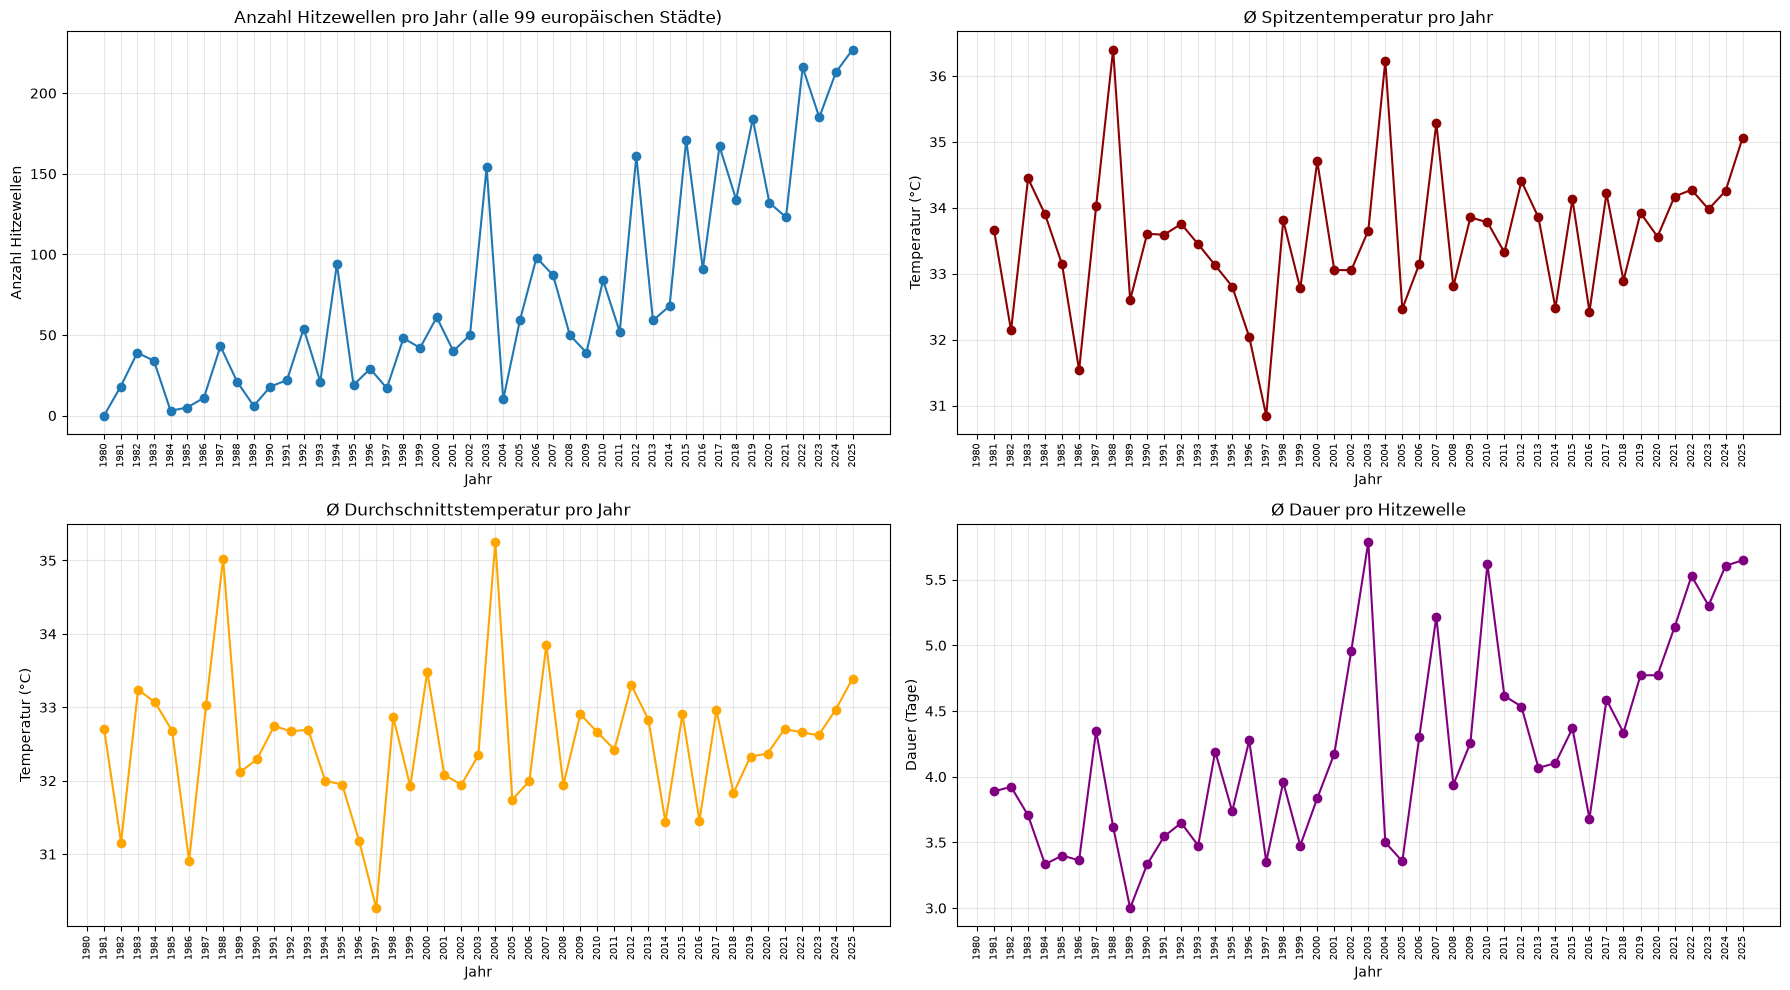

In [45]:
# Zelle 26
import matplotlib.pyplot as plt
import numpy as np

n_cities = cities_df.drop(index=list(exclude_idx)).shape[0]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
all_years_range = np.arange(1980, 2026)

def style_axis(ax, ylabel):
    # gemeinsame Formatierung für alle vier Diagramme, damit wir sie nicht viermal einzeln wiederholen müssen
    ax.set_xlabel("Jahr")
    ax.set_ylabel(ylabel)
    ax.set_xticks(all_years_range)
    ax.set_xticklabels(all_years_range, rotation=90, fontsize=7)
    ax.grid(axis="x", alpha=0.3)
    ax.grid(axis="y", alpha=0.3)

axes[0,0].plot(yearly["year"], yearly["n_heatwaves"], marker="o")
axes[0,0].set_title(f"Anzahl Hitzewellen pro Jahr (alle {n_cities} europäischen Städte)")
style_axis(axes[0,0], "Anzahl Hitzewellen")

axes[0,1].plot(yearly["year"], yearly["avg_max_temp"], marker="o", color="darkred")
axes[0,1].set_title("Ø Spitzentemperatur pro Jahr")
style_axis(axes[0,1], "Temperatur (°C)")

axes[1,0].plot(yearly["year"], yearly["avg_avg_temp"], marker="o", color="orange")
axes[1,0].set_title("Ø Durchschnittstemperatur pro Jahr")
style_axis(axes[1,0], "Temperatur (°C)")

axes[1,1].plot(yearly["year"], yearly["avg_duration"], marker="o", color="purple")
axes[1,1].set_title("Ø Dauer pro Hitzewelle")
style_axis(axes[1,1], "Dauer (Tage)")

plt.tight_layout()
plt.savefig("data/processed/trend_overview_europe.png", dpi=150)
plt.show()

Zelle 27 — Trendstatistik (lineare Regression), gesamter Zeitraum

Ein Diagramm zeigt einen Trend nur visuell — hier wird er in Zahlen gefasst. Für jede Kennzahl wird eine lineare Regression über die Jahre gerechnet (`scipy.stats.linregress`), die vier Werte liefert:

- **slope**: die Steigung, also "wie viel ändert sich die Kennzahl pro Jahr im Schnitt" (z. B. +4,0 Hitzewellen/Jahr).
- **p-Wert**: wie wahrscheinlich es wäre, einen mindestens so starken Trend rein zufällig zu beobachten, wenn es in Wirklichkeit gar keinen gäbe. Kleiner ist hier "sicherer" — als Faustregel gilt ein Trend ab p < 0,05 als "statistisch signifikant", also unwahrscheinlich reiner Zufall.
- **R²**: wie viel der Schwankung von Jahr zu Jahr sich allein durch die Zeit erklären lässt (0 = gar nichts, 1 = alles). Ein niedriges R² bei signifikantem p-Wert heißt: es gibt zwar einen echten Trend, aber viel "Rauschen" um ihn herum.

`n` zeigt, wie viele Jahre tatsächlich in die Rechnung eingegangen sind — bei den Temperatur-/Dauerspalten kann das kleiner als 46 sein, weil Jahre ganz ohne Hitzewelle dort als NaN (nicht als 0) behandelt und rausgefiltert werden (`dropna`), siehe Zelle 24.

In [46]:
# Zelle 28
from scipy import stats

for col, label in [("n_heatwaves", "Häufigkeit"), ("avg_max_temp", "Spitzentemp."),
                    ("avg_avg_temp", "Durchschnittstemp."), ("avg_duration", "Dauer")]:
    valid = yearly.dropna(subset=[col])  # Jahre ohne Wert (kein Heatwave-Ereignis) rausfiltern
    slope, intercept, r, p, se = stats.linregress(valid["year"], valid[col])
    signif = "signifikant" if p < 0.05 else "nicht signifikant"
    print(f"{label}: {slope:+.3f}/Jahr, p={p:.4f} ({signif}), R²={r**2:.3f}, n={len(valid)}")

Häufigkeit: +3.995/Jahr, p=0.0000 (signifikant), R²=0.675, n=46
Spitzentemp.: +0.016/Jahr, p=0.1854 (nicht signifikant), R²=0.040, n=45
Durchschnittstemp.: +0.004/Jahr, p=0.6896 (nicht signifikant), R²=0.004, n=45
Dauer: +0.039/Jahr, p=0.0000 (signifikant), R²=0.473, n=45


Zelle 29 — Trendstatistik ohne Überlappungszeitraum

Die Referenzperiode (1961–1990) und der Analysezeitraum (1980–2025) überlappen sich in den Jahren 1980–1990 — diese 11 Jahre fließen also in beides ein. Um auszuschließen, dass das die Trendberechnung verzerrt (die Referenzperiode selbst enthält ja per Definition "durchschnittliches" Wetter, das könnte den frühen Teil des Analysezeitraums künstlich unauffällig aussehen lassen), wird dieselbe Regression hier ein zweites Mal gerechnet, aber nur für die Jahre ab 1991. Zeigen beide Rechnungen ein ähnliches Bild, ist das ein gutes Zeichen, dass der Trend nicht bloß ein Artefakt der Überlappung ist.

In [47]:
# Zelle 30
yearly_no_overlap = yearly[yearly["year"] >= 1991]

for col, label in [("n_heatwaves", "Häufigkeit"), ("avg_max_temp", "Spitzentemp."),
                    ("avg_avg_temp", "Durchschnittstemp."), ("avg_duration", "Dauer")]:
    valid = yearly_no_overlap.dropna(subset=[col])
    slope, intercept, r, p, se = stats.linregress(valid["year"], valid[col])
    signif = "signifikant" if p < 0.05 else "nicht signifikant"
    print(f"{label} (nur 1991–2025, keine Überlappung): {slope:+.3f}/Jahr, p={p:.4f} ({signif}), R²={r**2:.3f}, n={len(valid)}")

Häufigkeit (nur 1991–2025, keine Überlappung): +5.015/Jahr, p=0.0000 (signifikant), R²=0.632, n=35
Spitzentemp. (nur 1991–2025, keine Überlappung): +0.032/Jahr, p=0.0566 (nicht signifikant), R²=0.106, n=35
Durchschnittstemp. (nur 1991–2025, keine Überlappung): +0.015/Jahr, p=0.3058 (nicht signifikant), R²=0.032, n=35
Dauer (nur 1991–2025, keine Überlappung): +0.046/Jahr, p=0.0000 (signifikant), R²=0.402, n=35
